In [1]:
using ITensors, ITensorMPS
using ITransverse
using ITensorExpMPO
using ITensors: Algorithm
using Plots
using Plots.PlotMeasures
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)


using LsqFit

using Revise
includet("main.jl")

In [3]:
function analyze_alcaraz_dynamics(
    mpo_generator::Function, target_times::Vector{Float64};
    p::Float64=0.0, lambda::Float64=1.0, dt::Float64=0.1,
    cutoff::Float64=1e-12, maxdim::Int=256, 
    alg::String="RTM", eps_converged::Float64=1e-6, nbeta::Int=4, MPO_alg::String="VD2"
)
    center_entropies = Float64[]
    rate_functions = Float64[]

    plt_real = plot(title="Re(S₂) Entropy Profiles", xlabel="Temporal Cut (t/T)", 
                    ylabel="Re(S₂)", legend=:outerright, grid=true, framestyle=:box)
    
    plt_imag = plot(title="Im(S₂) Entropy Profiles", xlabel="Temporal Cut (t/T)", 
                    ylabel="Im(S₂)", legend=:outerright, grid=true, framestyle=:box)

    n_times = length(target_times)
    colors = cgrad(:viridis, n_times, categorical=true)

    @showprogress for (i, T) in enumerate(target_times)
        # Compute Entropies & States
        bonds, r2_re, r2_im, psi_L, psi_R, mpo = compute_alcaraz_entropies(
            mpo_generator, T; 
            lambda=lambda, p=p, dt=dt, cutoff=cutoff, maxdim=maxdim, 
            alg=alg, eps_converged=eps_converged, nbeta=nbeta, MPO_alg=MPO_alg
        )
        
        # Plot Profiles
        x_norm = range(0.0, 1.0, length=length(r2_re))
        plot!(plt_real, x_norm, r2_re, label="T=$(round(T, digits=1))", lw=2, color=colors[i])
        plot!(plt_imag, x_norm, r2_im, label="T=$(round(T, digits=1))", lw=2, color=colors[i])

        # Center Entropy
        center_idx = length(r2_re) ÷ 2
        push!(center_entropies, r2_re[center_idx])

        # Loschmidt Rate Function: l(T) = -ln(|λ₀|)
        overlap_0 = overlap_noconj(psi_L, psi_R)
        if isnan(abs(overlap_0)) || abs(overlap_0) < 1e-25
            push!(rate_functions, NaN)
        else
            Lambda_0 = expval_LR(psi_L, mpo, psi_R) / overlap_0
            push!(rate_functions, -log(abs(Lambda_0)))
        end
    end

    # Plot Bottom-Left: Center Entropy vs T
    plt_center = plot(target_times, center_entropies, lw=2, marker=:circle,
                      title="Center Entropy vs T", xlabel="T", ylabel="Re(S₂) at Center",
                      legend=false, grid=true, framestyle=:box, color=:blue)

    # Plot Bottom-Right: Loschmidt Rate Function
    plt_dqpt = plot(target_times, rate_functions, lw=2, marker=:circle, markersize=5,
                    title="Loschmidt Echoes", 
                    xlabel="Time (T)", ylabel="Rate Function l(T) ∝ -ln|λ₀|", 
                    color=:red, legend=false, grid=true, framestyle=:box)

    final_layout = plot(
        plt_real, plt_imag, plt_center, plt_dqpt, 
        layout=(2, 2), 
        size=(1200, 1000), 
        margin=5Plots.mm,
        plot_title="Alcaraz Dynamics: Entropy & DQPT Benchmarking (p=$p, λ=$lambda)"
    )
    
    return final_layout
end

analyze_alcaraz_dynamics (generic function with 1 method)

---

Let us first compute the intensive Loschmidt echo using a la Schrodinger time evolution

In [2]:
function benchmark_loschmidt_mpo_only(
    N::Int, target_times::Vector{Float64};
    p::Float64=0.1, lambda::Float64=1.0, dt::Float64=0.05,
    cutoff::Float64=1e-10, maxdim::Int=128, mpo_alg::String="VD2"
)
    # Setup finite chain
    sites = siteinds("S=1/2", N)
    
    psi0 = complex(MPS(sites, "X+"))
    
    U_dt = expH_alcaraz(sites, lambda, p; dt=dt, mpo_alg=mpo_alg)
    
    rate_MPO = Float64[]
    
    psi_t = deepcopy(psi0)
    current_t = 0.0
    
    @showprogress "Schrödinger MPO Evolution (N=$N)..." for T in target_times
        # Number of steps to reach target T from current_t
        steps = round(Int, (T - current_t) / dt)
        
        for _ in 1:steps
            psi_t = apply(U_dt, psi_t; cutoff=cutoff, maxdim=maxdim)
            normalize!(psi_t) 
        end
        current_t = T
        
        # Loschmidt Overlap: G(t) = <psi(0) | psi(t)>
        G_MPO = inner(psi0, psi_t)
        
        # Rate function: l(t) = (-1/N) * ln(|G(t)|)
        push!(rate_MPO, -log(max(abs(G_MPO), 1e-50)) / N)
        
        GC.gc()
    end
    
    # Plotting
    plt = plot(
        target_times, rate_MPO, 
        label="MPO Alg: $mpo_alg (maxdim=$maxdim)", 
        lw=2, marker=:circle, color=:blue,
        title="Loschmidt Echo Rate (N=$N)",
        xlabel="Time (t)", 
        ylabel="Rate Function l(t)", 
        grid=true, framestyle=:box, legend=:topleft
    )
    
    return plt, rate_MPO
end

benchmark_loschmidt_mpo_only (generic function with 1 method)

Schrödinger MPO Evolution (N=100)... 100%|███████████████| Time: 1:25:28


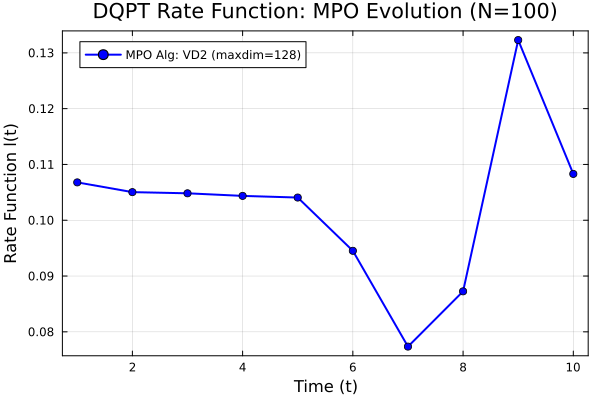

In [3]:
dense_times = collect(1.0:1.0:10.0) 
N_spins = 100

schrodinger_plot, r_MPO = benchmark_loschmidt_mpo_only(
    N_spins, 
    dense_times;
    p=0.1, 
    lambda=1.0,
    dt=0.05,
    cutoff=1e-10, 
    maxdim=128, 
    mpo_alg="VD2"
)

display(schrodinger_plot)

Schrödinger MPO Evolution (N=100)... 100%|███████████████| Time: 0:45:54


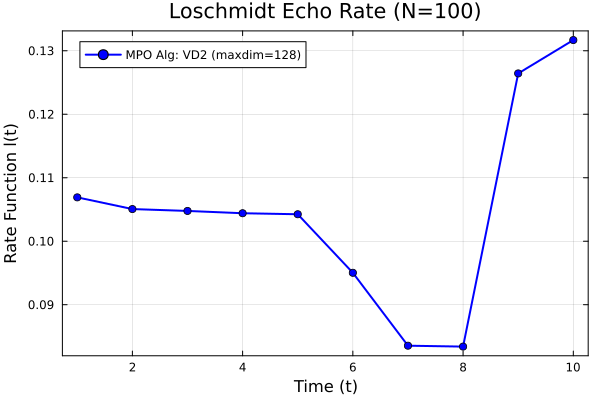

In [ ]:
dense_times = collect(1.0:1.0:10.0) 
N_spins = 100

schrodinger_plot, r_MPO = benchmark_loschmidt_mpo_only(
    N_spins, 
    dense_times;
    p=0.1, 
    lambda=1.0,
    dt=0.1,
    cutoff=1e-10, 
    maxdim=128, 
    mpo_alg="VD2"
)

display(schrodinger_plot)

Schrödinger MPO Evolution (N=200)... 100%|███████████████| Time: 0:59:23


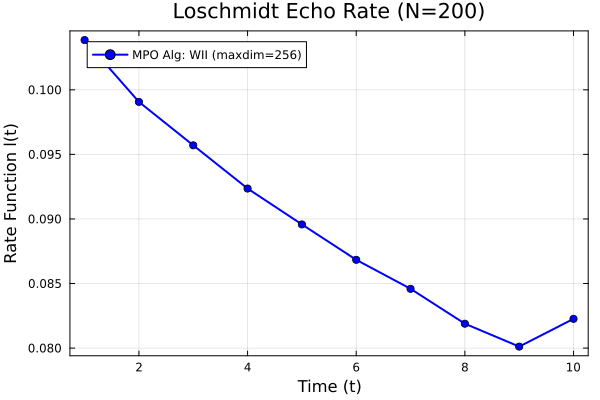

In [12]:
dense_times = collect(1.0:1.0:10.0) 
N_spins = 200

schrodinger_plot, r_MPO = benchmark_loschmidt_mpo_only(
    N_spins, 
    dense_times;
    p=0.1, 
    lambda=1.0,
    dt=0.1,
    cutoff=1e-10, 
    maxdim=256, 
    mpo_alg="WII"
)

display(schrodinger_plot)

Schrödinger MPO Evolution (N=200)... 100%|███████████████| Time: 4:59:42


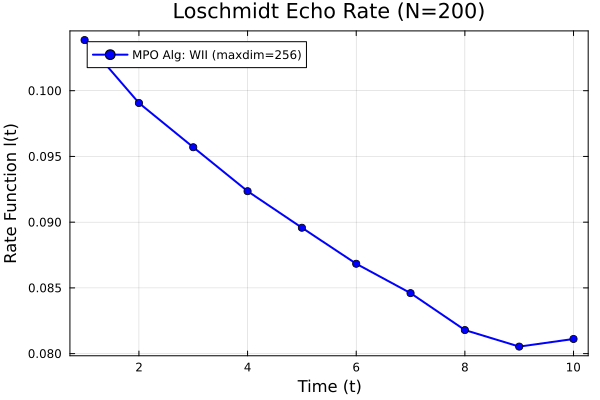

In [11]:
dense_times = collect(1.0:1.0:10.0) 
N_spins = 200

schrodinger_plot, r_MPO = benchmark_loschmidt_mpo_only(
    N_spins, 
    dense_times;
    p=0.1, 
    lambda=1.0,
    dt=0.1,
    cutoff=1e-14, 
    maxdim=256, 
    mpo_alg="WII"
)

display(schrodinger_plot)

now with TVDP

In [7]:
function benchmark_loschmidt_tvdp(
    N::Int, target_times::Vector{Float64};
    p::Float64=0.1, lambda::Float64=1.0, dt::Float64=0.05,
    cutoff::Float64=1e-10, maxdim::Int=128
)
    sites = siteinds("S=1/2", N)
    
    psi0 = complex(MPS(sites, "X+"))
    
    os = alcaraz_opsum(N, lambda, p)
    H = MPO(os, sites)
    
    rate_TDVP = Float64[]
    
    psi_t = deepcopy(psi0)
    current_t = 0.0
    
    @showprogress "Schrödinger TDVP Evolution (N=$N)..." for T in target_times
        # Number of steps to reach target T from current_t
        steps = round(Int, (T - current_t) / dt)
        
        for _ in 1:steps
            # We use nsite=2 to allow the bond dimension (entanglement) to grow dynamically
            psi_t = tdvp(H, -im * dt, psi_t; cutoff=cutoff, maxdim=maxdim)
            normalize!(psi_t) 
        end
        current_t = T
        
        # Loschmidt Overlap: G(t) = <psi(0) | psi(t)>
        G_TDVP = inner(psi0, psi_t)
        
        # Rate function: l(t) = (-1/N) * ln(|G(t)|)
        push!(rate_TDVP, -log(max(abs(G_TDVP), 1e-50)) / N)
        
        GC.gc()
    end
    
    plt = plot(
        target_times, rate_TDVP, 
        label="TDVP (nsite=2, maxdim=$maxdim)", 
        lw=2, marker=:cross, ls=:dash, color=:red,
        title="Loschmidt Echo Rate (N=$N)",
        xlabel="Time (t)", 
        ylabel="Rate Function l(t)", 
        grid=true, framestyle=:box, legend=:topleft
    )
    
    return plt, rate_TDVP
end

benchmark_loschmidt_tvdp (generic function with 1 method)

In [8]:
dense_times = collect(1.0:1.0:10.0) 
N_spins = 200

tvdp_plot, rate_tvdp = benchmark_loschmidt_tvdp(
    N_spins, 
    dense_times;
    p=0.1,
    lambda=1.0,
    dt=0.1,
    cutoff=1e-12, 
    maxdim=256, 
)

display(tvdp_plot)

Schrödinger TDVP Evolution (N=200)...  20%|██▊           |  ETA: 0:21:58

LoadError: InterruptException:

---

[PM LR|RTM] L=104, cutoff=1.0e-15, maxdim=256, normalize=overlap)  26%  ETA: 0:36:36 ( 0.60  s/it)
   Info: [1314]  chi=18 | ds=5.19244859935597e-5 | <R|Rprev> = -6.383201018610708e-8┌ Warning: PM Stuck after 201/1315 steps | ds=5.856193093159434e-5 | chi=18)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151
Progress: 100%|█████████████████████████████████████████| Time: 0:31:23


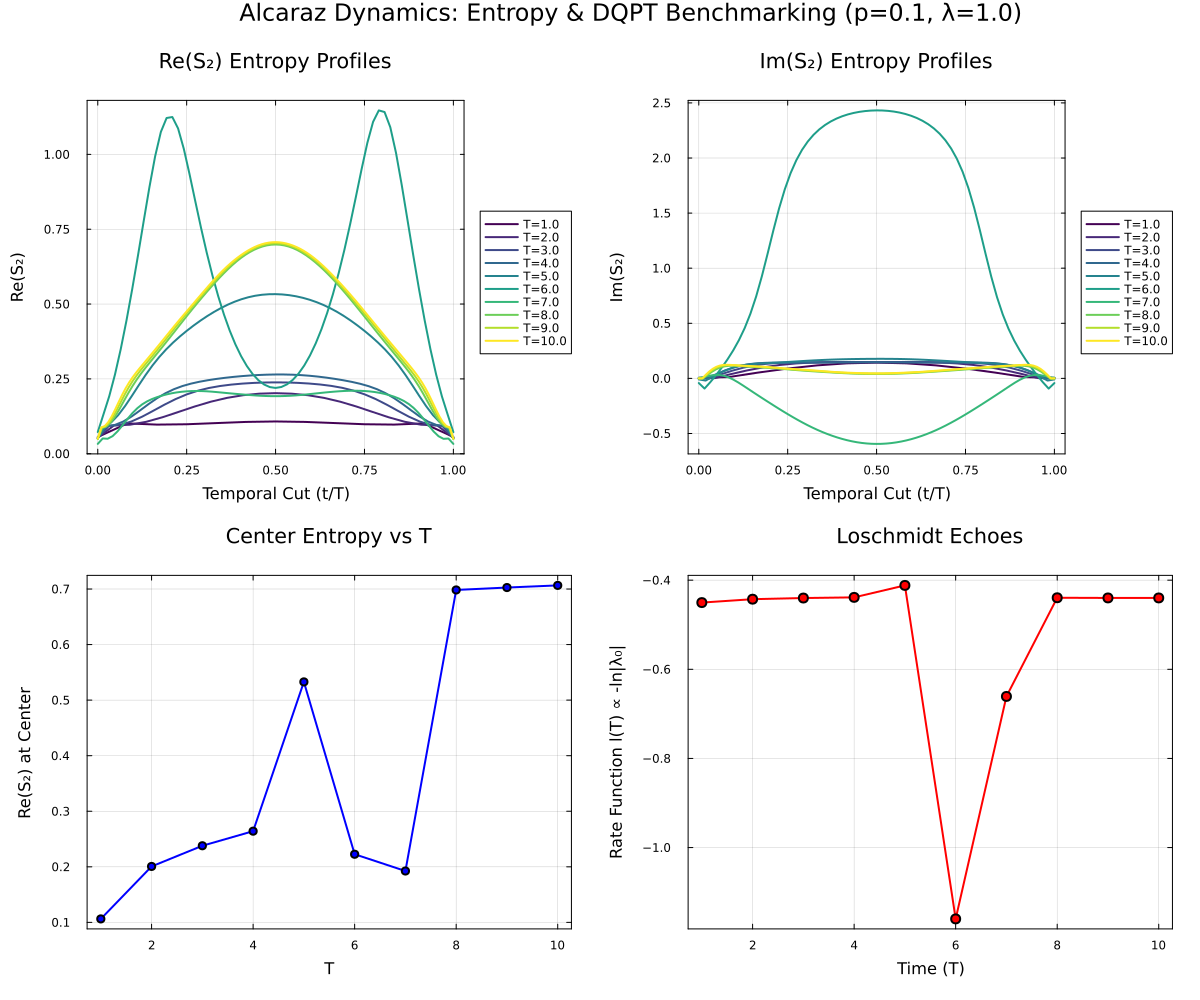

In [5]:
dense_times = collect(1.0:1.0:10.0) 

dynamics_plot = analyze_alcaraz_dynamics(
    expH_alcaraz, 
    dense_times;
    p = 0.1, 
    lambda = 1.0,
    dt = 0.1,
    cutoff = 1e-15, 
    maxdim = 256,
    MPO_alg = "VD2"
)

display(dynamics_plot)

[PM LR|RTM] L=204, cutoff=1.0e-15, maxdim=256, normalize=overlap)  46%  ETA: 1:00:02 ( 1.33  s/it)
   Info: [2292]  chi=18 | ds=0.00022339104515789465 | <R|Rprev> = -5.666232986550563e-6┌ Warning: PM Stuck after 201/2293 steps | ds=0.00020840990325710074 | chi=18)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151
Progress: 100%|█████████████████████████████████████████| Time: 2:00:32


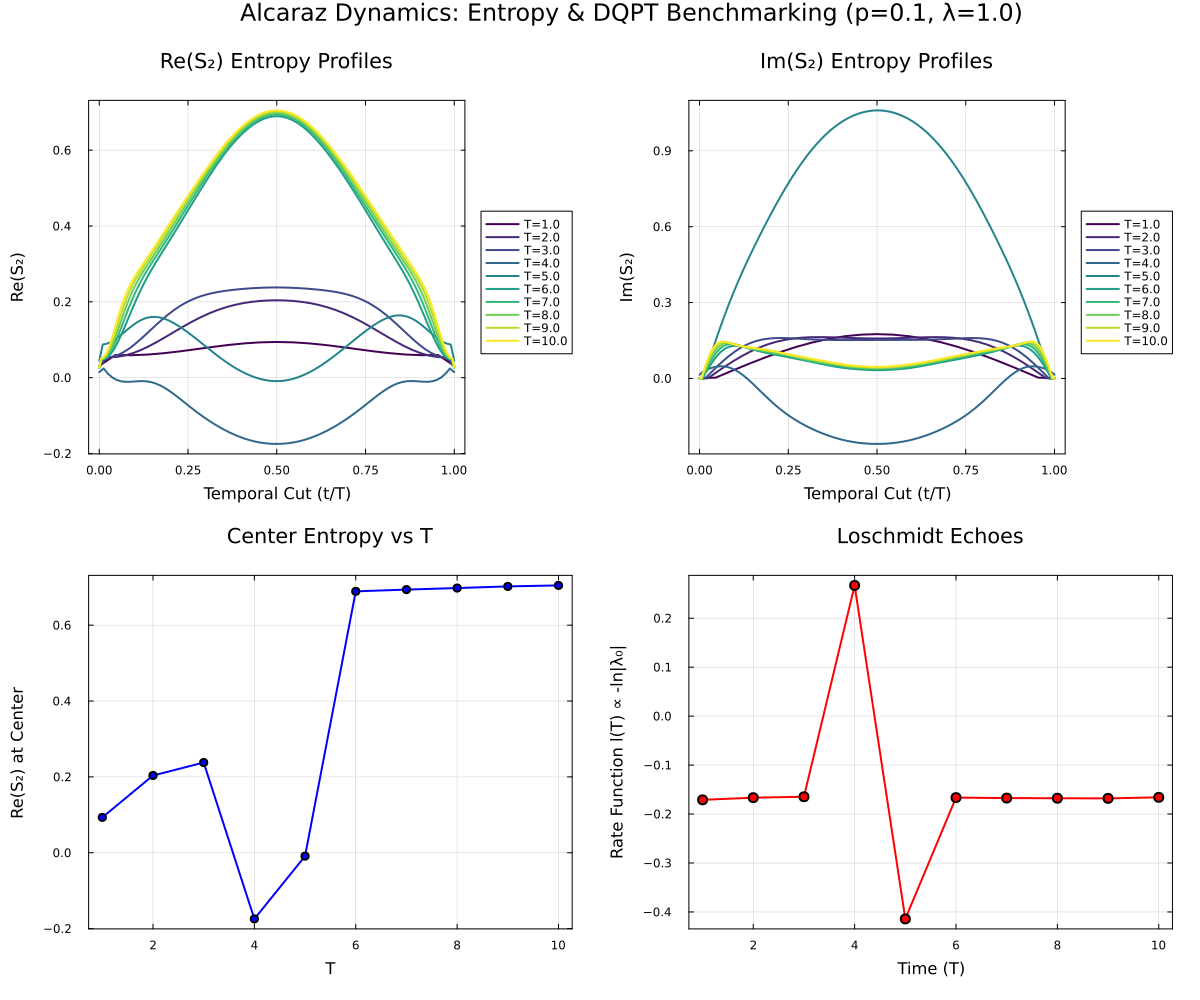

In [4]:
dense_times = collect(1.0:1.0:10.0) 

dynamics_plot = analyze_alcaraz_dynamics(
    expH_alcaraz, 
    dense_times;
    p = 0.1, 
    lambda = 1.0,
    dt = 0.05,
    cutoff = 1e-15, 
    maxdim = 256,
    MPO_alg = "VD2"
)

display(dynamics_plot)

[PM LR|RTM] L=104, cutoff=1.0e-15, maxdim=256, normalize=overlap)  22%  ETA: 0:08:36 ( 0.13  s/it)
   Info: [1110]  chi=18 | ds=0.00011036120102780878 | <R|Rprev> = -1.9878043027849327e-6┌ Warning: PM Stuck after 201/1111 steps | ds=0.00013072096608041095 | chi=18)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151
Progress: 100%|█████████████████████████████████████████| Time: 0:09:38


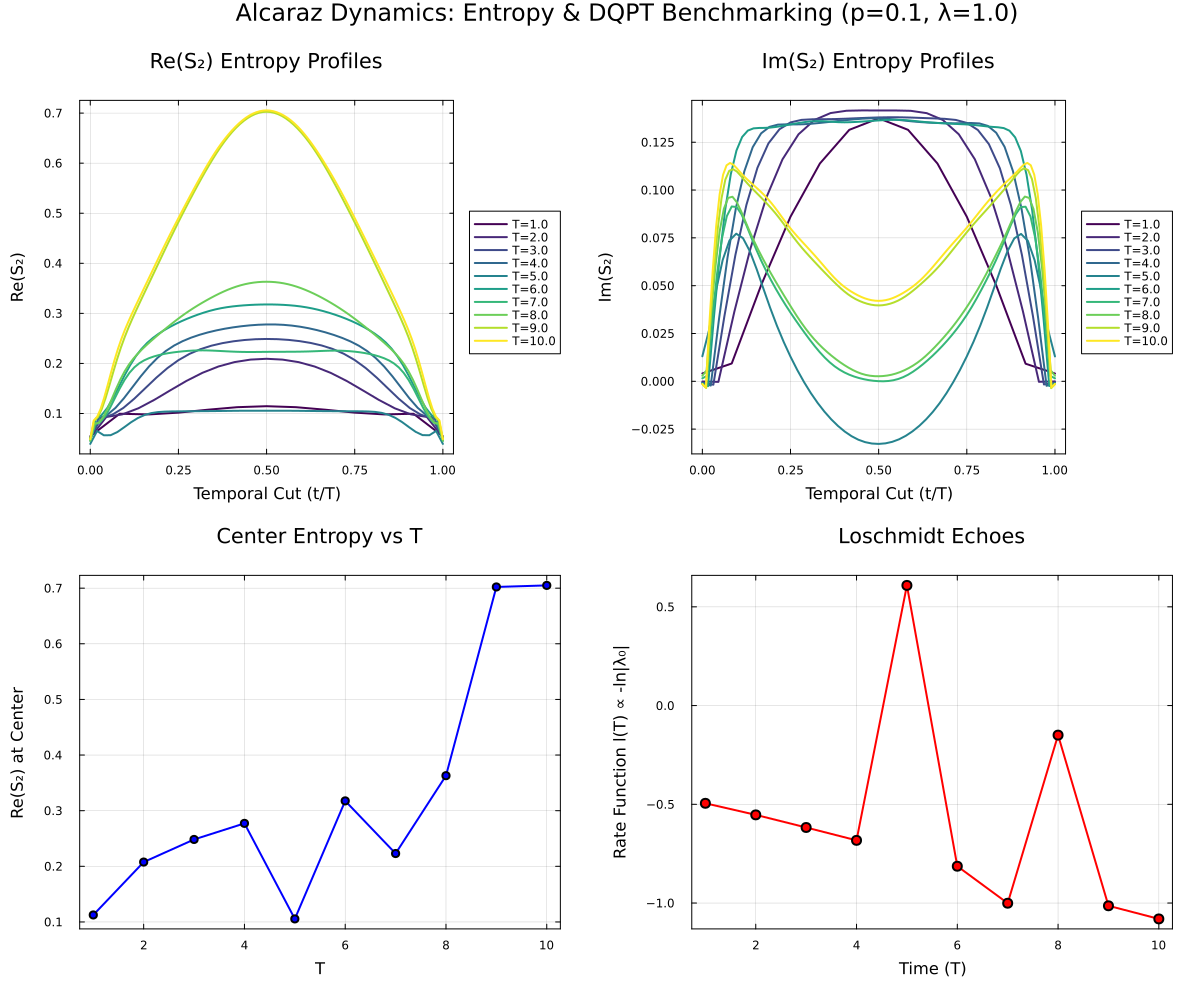

In [7]:
dense_times = collect(1.0:1.0:10.0) 

dynamics_plot = analyze_alcaraz_dynamics(
    expH_alcaraz, 
    dense_times;
    p = 0.1, 
    lambda = 1.0,
    dt = 0.1,
    cutoff = 1e-15, 
    maxdim = 256,
    MPO_alg = "WII"
)

display(dynamics_plot)

[PM LR|RTM] L=204, cutoff=1.0e-15, maxdim=256, normalize=overlap)  18%  ETA: 0:23:07 ( 0.34  s/it)
   Info: [893]  chi=18 | ds=0.00018688171757558214 | <R|Rprev> = -6.788227606016225e-7┌ Warning: PM Stuck after 201/894 steps | ds=6.291380908729494e-5 | chi=18)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151
Progress: 100%|█████████████████████████████████████████| Time: 0:21:11


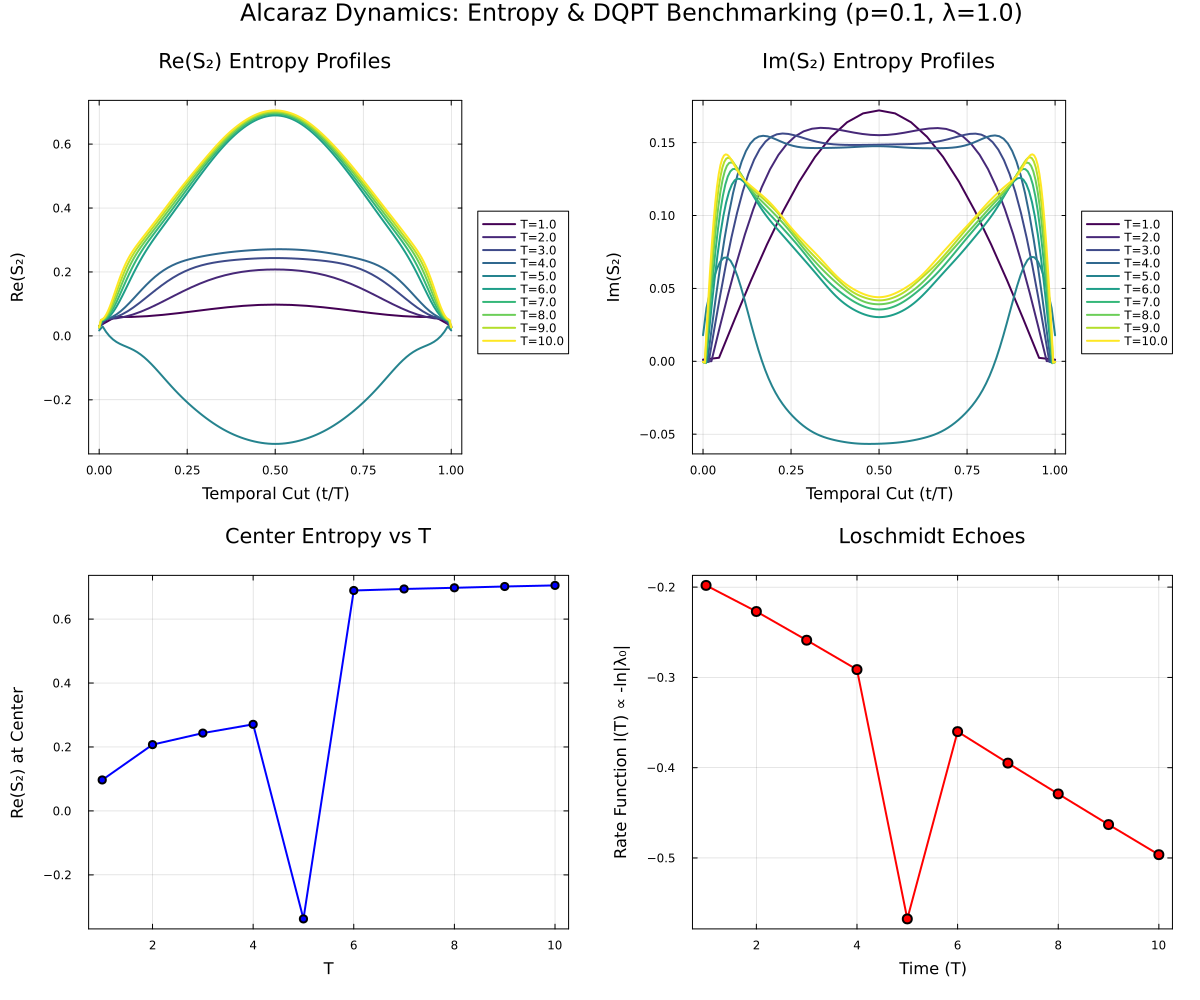

In [5]:
dense_times = collect(1.0:1.0:10.0) 

dynamics_plot = analyze_alcaraz_dynamics(
    expH_alcaraz, 
    dense_times;
    p = 0.1, 
    lambda = 1.0,
    dt = 0.05,
    cutoff = 1e-15, 
    maxdim = 256,
    MPO_alg = "WII"
)

display(dynamics_plot)